# Analisis Backtest Strategi Multi-Timeframe (MTF) Long-Only
## 1D Macro-Trend Filter + 1H Micro-Entry Trigger

**Notebook Riset Kuantitatif — Tugas Akhir (Skripsi)**

---

Notebook ini mengimplementasikan sistem trading deterministik MTF berbasis **Dynamic Trailing Stop Long-Only**
(menggunakan EMA 1D untuk melihat tren besar, dan RSI/MACD 1H untuk eksekusi presisi)
pada data S&P 500, NASDAQ 100, dan Dow Jones.

In [10]:
# =============================================================================
# SEL 1: FUNGSI PREPROCESSING & INDIKATOR MTF
# =============================================================================
import pandas as pd
import numpy as np

def load_data(filepath):
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df = pd.read_csv(filepath, sep='\t')
        col_name = 'DateTime' if 'DateTime' in df.columns else 'datetime'
        df['datetime_parsed'] = pd.to_datetime(df[col_name].str.replace('.', '-'), format='mixed', dayfirst=False)
        df.drop(columns=[col_name], inplace=True)
        df.rename(columns={'datetime_parsed': 'datetime'}, inplace=True)
    
    df.sort_values('datetime', inplace=True)
    df.drop_duplicates('datetime', inplace=True)
    df.rename(columns={'Open':'open', 'High':'high', 'Low':'low', 'Close':'close', 'Volume':'volume'}, inplace=True)
    df.columns = [c.lower() for c in df.columns]
    # Hapus kolom duplikat jika masih ada
    df = df.loc[:, ~df.columns.duplicated()]
    return df

def calc_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def calc_macd(series, fast=12, slow=26, signal=9):
    ema_fast = calc_ema(series, fast)
    ema_slow = calc_ema(series, slow)
    macd_line = ema_fast - ema_slow
    macd_signal = calc_ema(macd_line, signal)
    return macd_line, macd_signal

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def siapkan_data_mtf(f_1d, f_1h):
    df_1d = load_data(f_1d)
    df_1h = load_data(f_1h)
    
    # Terapkan Shift(1) agar data harian tidak mengandung lookahead bias!
    df_1d['ema_50_1d'] = calc_ema(df_1d['close'], 50).shift(1)
    df_1d['ema_100_1d'] = calc_ema(df_1d['close'], 100).shift(1)
    df_1d['ema_200_1d'] = calc_ema(df_1d['close'], 200).shift(1)
    df_1d['date'] = df_1d['datetime'].dt.date
    df_1d.drop_duplicates('date', keep='last', inplace=True)
    
    df_1h['date'] = df_1h['datetime'].dt.date
    
    # Gabungkan data 1D ke 1H
    df_merged = pd.merge(df_1h, df_1d[['date', 'ema_50_1d', 'ema_100_1d', 'ema_200_1d']], on='date', how='left')
    df_merged.ffill(inplace=True)
    df_merged.dropna(inplace=True)
    df_merged.reset_index(drop=True, inplace=True)
    
    # Indikator 1H Intraday
    df_merged['macd_line'], df_merged['macd_signal'] = calc_macd(df_merged['close'])
    df_merged['rsi'] = calc_rsi(df_merged['close'])
    df_merged.fillna(0, inplace=True)
    
    return df_merged

print("[OK] Modul fungsi data berhasil dimuat.")

[OK] Modul fungsi data berhasil dimuat.


In [11]:
# =============================================================================
# SEL 2: MEMUAT ALIGNMENT DATA MTF UNTUK SELURUH INSTRUMEN
# =============================================================================
print("Memproses data Multi-Timeframe...")
d_files = {
    'SPY': ('TA/spy_US500_D1.parquet', 'TA/spy_US500_H1.parquet'),
    'NDX': ('TA/Nasdaq100_1d_data.csv', 'TA/Nasdaq100_1h_data.csv'),
    'DJI': ('TA/Dow_Jones_1d_data.csv', 'TA/Dow_Jones_1h_data.csv')
}

df_spy = siapkan_data_mtf(*d_files['SPY'])
print(f"  S&P 500 (SPY): {len(df_spy)} bar tersinkronisasi.")

df_ndx = siapkan_data_mtf(*d_files['NDX'])
print(f"  NASDAQ 100: {len(df_ndx)} bar tersinkronisasi.")

df_dji = siapkan_data_mtf(*d_files['DJI'])
print(f"  Dow Jones (DJI): {len(df_dji)} bar tersinkronisasi.")

print("\n[OK] Data 1D dan 1H berhasil digabungkan tanpa lookahead bias.")

Memproses data Multi-Timeframe...
  S&P 500 (SPY): 50172 bar tersinkronisasi.
  NASDAQ 100: 51871 bar tersinkronisasi.
  Dow Jones (DJI): 49303 bar tersinkronisasi.

[OK] Data 1D dan 1H berhasil digabungkan tanpa lookahead bias.


In [12]:
# =============================================================================
# SEL 3: MESIN STRATEGI MTF & TRAILING STOP
# =============================================================================
def simulasi_strategi_mtf(df_merged, nama_instrumen, biaya=0.0002):
    close_p = df_merged['close'].values
    high_p = df_merged['high'].values if 'high' in df_merged.columns else close_p
    low_p = df_merged['low'].values if 'low' in df_merged.columns else close_p
    
    ema_50_1d = df_merged['ema_50_1d'].values
    ema_100_1d = df_merged['ema_100_1d'].values
    ema_200_1d = df_merged['ema_200_1d'].values
    
    macd_line = df_merged['macd_line'].values
    macd_signal = df_merged['macd_signal'].values
    rsi = df_merged['rsi'].values
    
    p_state = np.zeros(len(df_merged))
    ret_strat = np.zeros(len(df_merged))
    trade_exec = np.zeros(len(df_merged))
    
    trailing_dist = 0.015
    extreme_tp = 0.05
    
    posisi = 0.0
    highest_price = 0.0
    sl_price = 0.0
    tp_price = 0.0
    
    rsi_cross = (pd.Series(rsi).shift(1) <= 50) & (pd.Series(rsi) > 50)
    rsi_cross = rsi_cross.values

    for i in range(1, len(df_merged)):
        if posisi == 0.0:
            if rsi_cross[i]:
                tren = (ema_50_1d[i] > ema_100_1d[i]) and (ema_100_1d[i] > ema_200_1d[i])
                mom = macd_line[i] > macd_signal[i]
                
                if tren and mom:
                    posisi = 1.0
                    entry_price = close_p[i]
                    highest_price = entry_price
                    sl_price = entry_price * (1 - trailing_dist)
                    tp_price = entry_price * (1 + extreme_tp)
                    
                    p_state[i] = 1.0
                    trade_exec[i] = 1.0
        elif posisi == 1.0:
            hit_tp = high_p[i] >= tp_price
            hit_sl = low_p[i] <= sl_price
            
            if hit_tp or hit_sl:
                posisi = 0.0
                p_state[i] = 0.0
                trade_exec[i] += 1.0
                exit_price = sl_price if hit_sl else tp_price
                ret_strat[i] = (exit_price / close_p[i-1]) - 1.0
            else:
                p_state[i] = 1.0
                ret_strat[i] = (close_p[i] / close_p[i-1]) - 1.0
                if high_p[i] > highest_price:
                    highest_price = high_p[i]
                    sl_price = max(sl_price, highest_price * (1 - trailing_dist))

    return_strategi = pd.Series(ret_strat, index=df_merged.index) - (pd.Series(trade_exec, index=df_merged.index) * biaya)
    return_strategi = return_strategi.fillna(0)
    
    return_kumulatif = (1 + return_strategi).cumprod()
    return_pasar = df_merged['close'].pct_change().fillna(0)
    return_bnh = (1 + return_pasar).cumprod()
    
    peak_kumulatif = return_kumulatif.cummax()
    drawdown = (return_kumulatif - peak_kumulatif) / peak_kumulatif
    
    df_merged['posisi'] = p_state
    
    # === LOG TRANSAKSI ===
    perubahan = pd.Series(trade_exec, index=df_merged.index)
    mask_transaksi = perubahan != 0
    log = df_merged.loc[mask_transaksi, ['datetime', 'close', 'rsi', 'posisi']].copy()
    perubahan_log = perubahan[mask_transaksi].values
    posisi_log = log['posisi'].values
    log['aksi'] = np.where(perubahan_log > 1, 'BUY & SELL', np.where((perubahan_log == 1) & (posisi_log == 1), 'LONG ENTRY', 'EXIT (TS/TP)'))
    log.set_index('datetime', inplace=True)
    
    print(f"  [{nama_instrumen}] Strategi selesai — Total transaksi/sinyal: {mask_transaksi.sum()}, Return akhir: {return_kumulatif.iloc[-1]:.4f}x")
    
    return {
        'nama': nama_instrumen,
        'return_strategi': return_strategi,
        'return_kumulatif': return_kumulatif,
        'return_bnh': return_bnh,
        'drawdown': drawdown,
        'log_transaksi': log,
        'posisi': df_merged['posisi'],
        'df_len': len(df_merged)
    }

print("Menjalankan simulasi strategi kuantitatif MTF (1D Trend + 1H Trigger)...\n")
hasil_spy = simulasi_strategi_mtf(df_spy, 'S&P 500 (SPY)')
hasil_ndx = simulasi_strategi_mtf(df_ndx, 'NASDAQ 100')
hasil_dji = simulasi_strategi_mtf(df_dji, 'Dow Jones (DJI)')

daftar_hasil = [hasil_spy, hasil_ndx, hasil_dji]
print("\n" + "="*60)
print("[OK] Simulasi MTF selesai.")

Menjalankan simulasi strategi kuantitatif MTF (1D Trend + 1H Trigger)...

  [S&P 500 (SPY)] Strategi selesai — Total transaksi/sinyal: 628, Return akhir: 1.3556x
  [NASDAQ 100] Strategi selesai — Total transaksi/sinyal: 887, Return akhir: 2.1786x
  [Dow Jones (DJI)] Strategi selesai — Total transaksi/sinyal: 575, Return akhir: 1.3663x

[OK] Simulasi MTF selesai.


In [13]:
# =============================================================================
# SEL 4: EVALUASI METRIK KINERJA 
# =============================================================================
results = []
bars_per_tahun = 252 * 24

for h in daftar_hasil:
    return_kumulatif = h['return_kumulatif']
    return_strategi = h['return_strategi']
    df_len = h['df_len']
    pos_series = h['posisi']
    
    cagr = (return_kumulatif.iloc[-1] ** (bars_per_tahun / df_len)) - 1
    ann_vol = return_strategi.std() * np.sqrt(bars_per_tahun)
    sharpe = (return_strategi.mean() * bars_per_tahun) / ann_vol if ann_vol != 0 else 0
    
    neg_ret = return_strategi[return_strategi < 0]
    downside_std = neg_ret.std() * np.sqrt(bars_per_tahun)
    sortino = (return_strategi.mean() * bars_per_tahun) / downside_std if downside_std > 0 else 0
    
    max_dd = h['drawdown'].min() * 100
    
    perubahan = pos_series.diff().fillna(pos_series)
    idx_perubahan = perubahan[perubahan != 0].index
    
    trade_returns = []
    i = 0
    while i < len(idx_perubahan):
        pos_val = pos_series.loc[idx_perubahan[i]]
        if pos_val != 0:
            start = idx_perubahan[i]
            exit_found = False
            for j in range(i+1, len(idx_perubahan)):
                if pos_series.loc[idx_perubahan[j]] == 0:
                    end = idx_perubahan[j]
                    trade_ret = return_strategi.loc[start:end]
                    trade_cum = (1 + trade_ret).prod() - 1
                    trade_returns.append(trade_cum)
                    i = j + 1
                    exit_found = True
                    break
            if not exit_found:
                trade_ret = return_strategi.loc[start:]
                trade_cum = (1 + trade_ret).prod() - 1
                trade_returns.append(trade_cum)
                break
        else:
            i += 1
            
    trade_returns = np.array(trade_returns)
    total_trades = len(trade_returns)
    
    winning = trade_returns[trade_returns > 0]
    win_rate = len(winning) / total_trades * 100 if total_trades > 0 else 0
    
    gross_profit = winning.sum() if len(winning) > 0 else 0
    losing = trade_returns[trade_returns < 0]
    gross_loss = abs(losing.sum()) if len(losing) > 0 else 1e-10
    profit_factor = gross_profit / gross_loss
    
    res = {
        'Instrumen': h['nama'],
        'Total Cumulative Return (%)': (return_kumulatif.iloc[-1] - 1) * 100,
        'CAGR (%)': cagr * 100,
        'Annualized Volatility (%)': ann_vol * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_dd,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor,
        'Total Trades': total_trades
    }
    results.append(res)

df_res = pd.DataFrame(results)
df_res.set_index('Instrumen', inplace=True)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("=" * 140)
print("RINGKASAN KINERJA KOMPARATIF — STRATEGI MTF (1D TREND + 1H TRIGGER)")
print("=" * 140)
print("\n" + df_res.to_string())

RINGKASAN KINERJA KOMPARATIF — STRATEGI MTF (1D TREND + 1H TRIGGER)

                 Total Cumulative Return (%)  CAGR (%)  Annualized Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                                                  
S&P 500 (SPY)                        35.5621    3.7358                     9.3878        0.4377         0.3956          -15.0537       39.8089         1.1968           314
NASDAQ 100                          117.8634    9.5043                    10.8575        0.8906         0.7562          -18.2315       37.3874         1.3420           444
Dow Jones (DJI)                      36.6345    3.9033                     8.9314        0.4734         0.4371          -21.7810       35.7639         1.2162           288


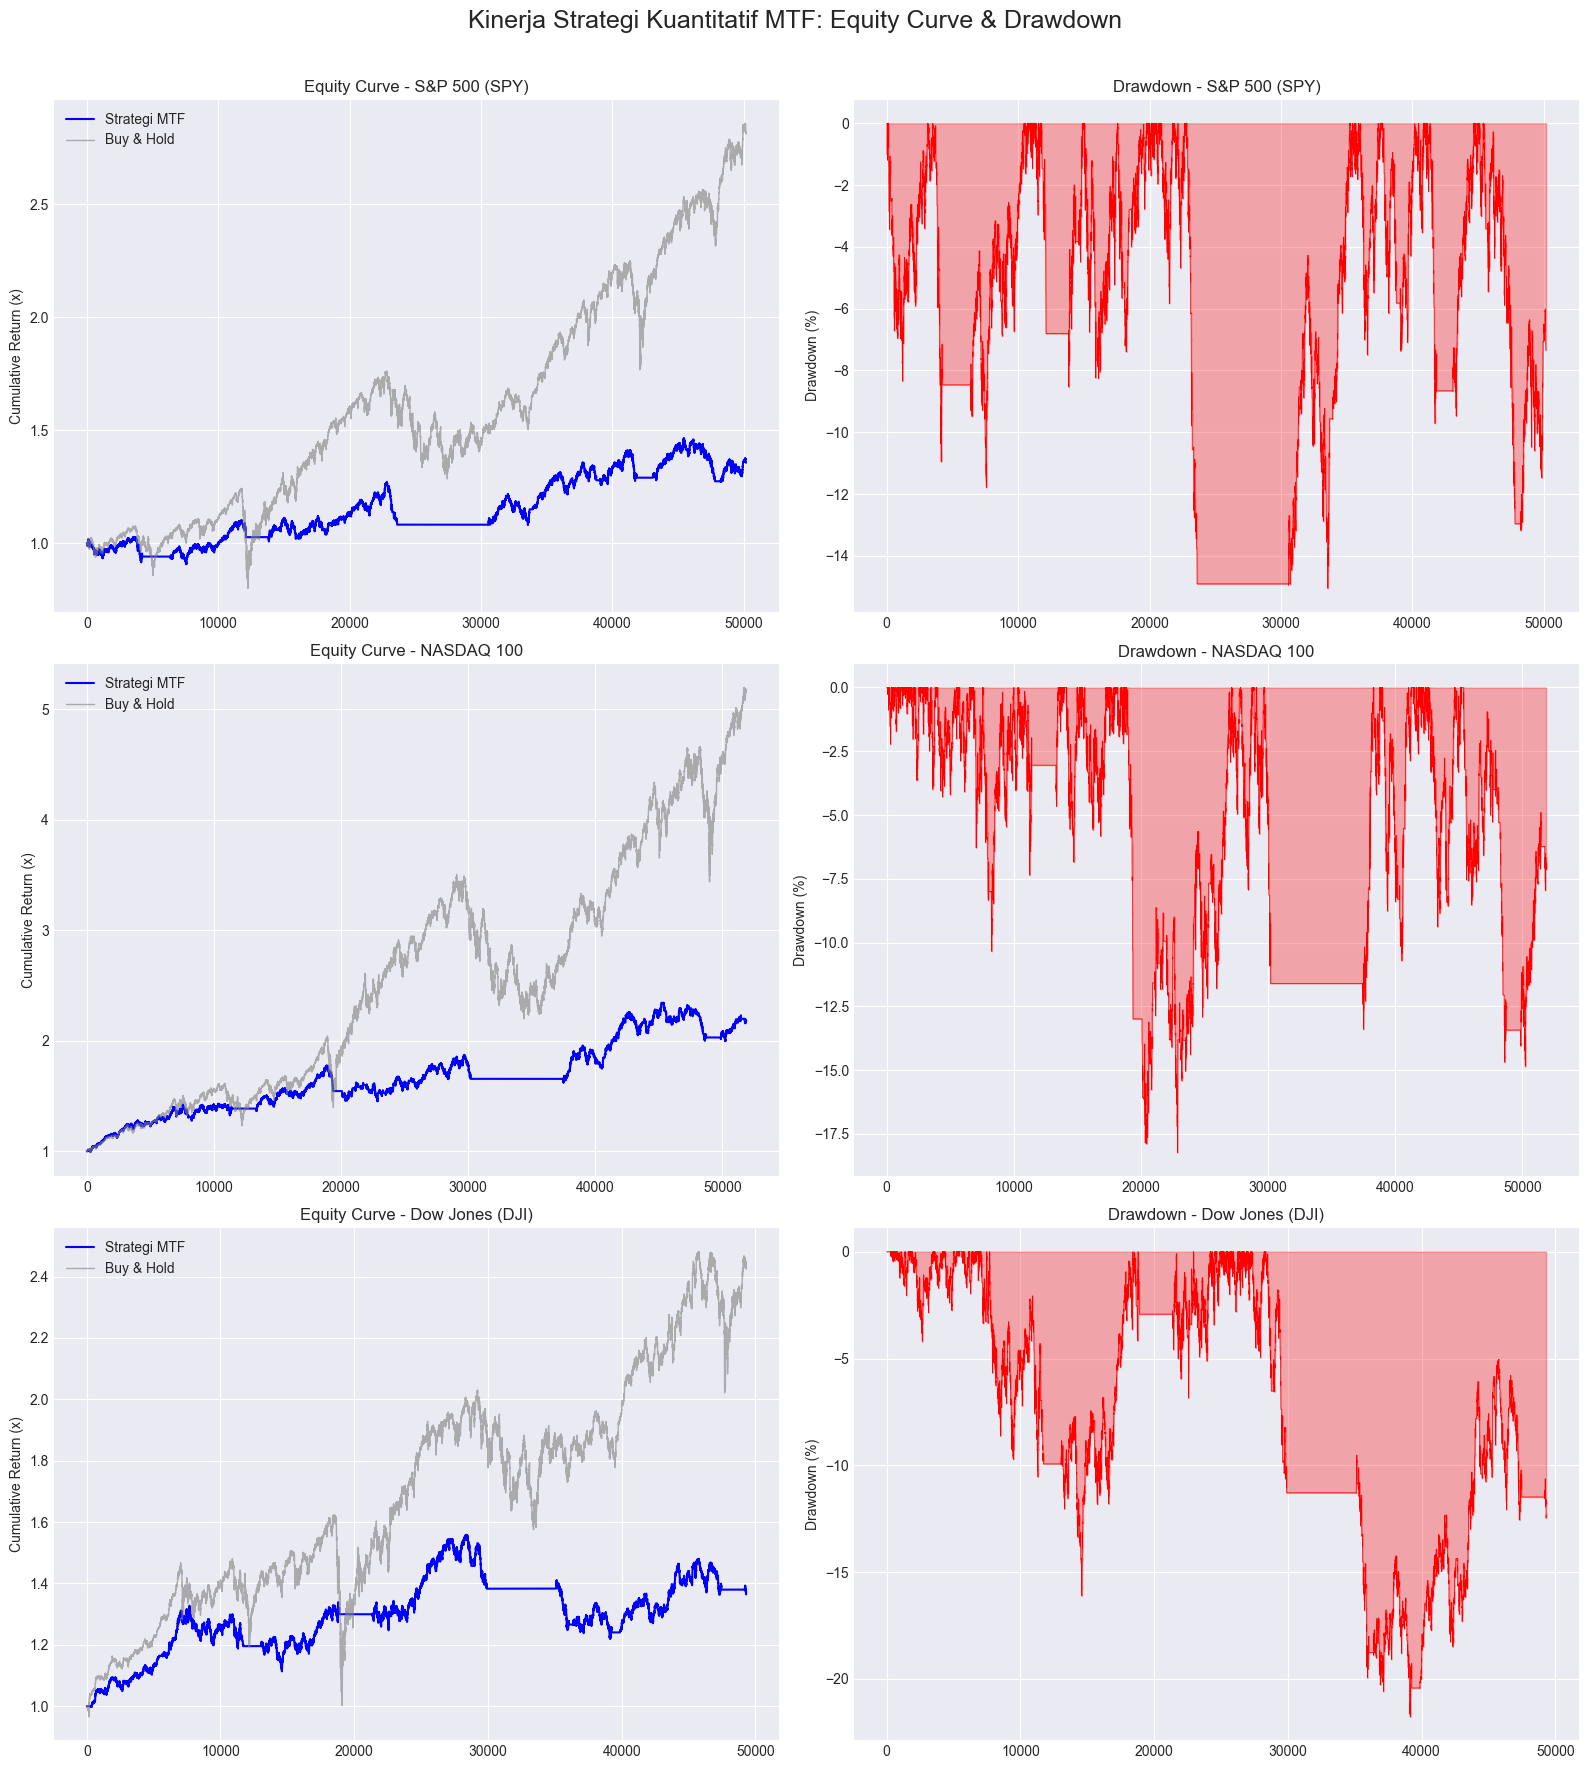

SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis

--- S&P 500 (SPY) ---
Total transaksi tercatat: 628
                        Close  RSI(14)  Posisi          Aksi
datetime                                                    
2026-07-08 21:00:00 7479.9000  50.7547  1.0000    LONG ENTRY
2026-07-17 07:00:00 7471.2000  20.9689  0.0000  EXIT (TS/TP)
2026-07-20 10:00:00 7476.9000  50.6582  1.0000    LONG ENTRY
2026-07-23 16:00:00 7419.6000  28.7069  0.0000  EXIT (TS/TP)
2026-07-24 12:00:00 7429.0000  50.3529  1.0000    LONG ENTRY
2026-07-29 17:00:00 7371.0000  33.9486  0.0000  EXIT (TS/TP)
2026-07-30 14:00:00 7368.1000  50.7459  1.0000    LONG ENTRY
2026-08-04 20:00:00 7740.5000  90.8943  0.0000  EXIT (TS/TP)
2026-08-07 11:00:00 7720.3000  52.7152  1.0000    LONG ENTRY
2026-08-18 11:00:00 7710.1000  22.1990  0.0000  EXIT (TS/TP)

--- NASDAQ 100 ---
Total transaksi tercatat: 887
                         Close  RSI(14)  Posisi          Aksi
datetime                               

In [14]:
# =============================================================================
# SEL 5: VISUALISASI EQUITY CURVE & LOG TRANSAKSI
# =============================================================================
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Kinerja Strategi Kuantitatif MTF: Equity Curve & Drawdown', fontsize=18, y=0.98)

for i, h in enumerate(daftar_hasil):
    ax_eq = axes[i, 0]
    ax_eq.plot(h['return_kumulatif'].values, label='Strategi MTF', color='blue', linewidth=1.5)
    ax_eq.plot(h['return_bnh'].values, label='Buy & Hold', color='gray', alpha=0.6, linewidth=1)
    ax_eq.set_title(f"Equity Curve - {h['nama']}")
    ax_eq.set_ylabel('Cumulative Return (x)')
    ax_eq.legend()
    
    ax_dd = axes[i, 1]
    ax_dd.fill_between(range(len(h['drawdown'])), h['drawdown'].values * 100, 0, color='red', alpha=0.3)
    ax_dd.plot(h['drawdown'].values * 100, color='red', linewidth=0.5)
    ax_dd.set_title(f"Drawdown - {h['nama']}")
    ax_dd.set_ylabel('Drawdown (%)')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('mtf_equity_drawdown_chart.png')
plt.show()

print("================================================================================")
print("SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis")
print("================================================================================")
for h in daftar_hasil:
    log = h['log_transaksi']
    print(f"\n--- {h['nama']} ---")
    print(f"Total transaksi tercatat: {len(log)}")
    if len(log) > 0:
        tampilan = log.tail(10)[['close', 'rsi', 'posisi', 'aksi']].copy()
        tampilan.columns = ['Close', 'RSI(14)', 'Posisi', 'Aksi']
        print(tampilan.to_string())
    else:
        print("  Tidak ada transaksi tercatat.")